In [ ]:
# import requests
# import json

# api_key = 'Key <RIPE_ATLAS_API_KEY>'

# probe_id = 1005644

# # unix time
# start_time = 1641062400
# end_time = 1643625599

# # Define the API URL
# api_url = 'https://atlas.ripe.net/api/v2/probes/' + probe_id + '/results/?status=1&start=' + start_time + '&stop=' + end_time

# # Set the headers to include your API key
# headers = {'Content-Type': 'application/json', 'Authorization': 'Key ' + api_key}

# # Send the API request and store the response
# response = requests.get(api_url, headers=headers)

# # Convert the response to JSON format
# data = json.loads(response.text)

# data

# # Get the number of successful results
# # success_count = len(data['results'])

# # # Calculate the uptime percentage
# # uptime_percentage = (success_count / (int(end_time) - int(start_time))) * 100

# # # Print the uptime percentage
# # print('Probe uptime percentage: ' + str(uptime_percentage) + '%')


In [ ]:
## to find how many probes support both


In [ ]:
import requests

# Define the API URL to get a list of all RIPE Atlas probes
api_url = "https://atlas.ripe.net/api/v2/probes/?status=1"

# Send the API request and store the response
response = requests.get(api_url)

# Convert the response to JSON format
data = response.json()

print(data)

# Initialize a counter for the number of probes that support both IPv4 and IPv6
ipv4_ipv6_probes = 0

# # Loop through all probes and count the ones that support both IPv4 and IPv6
# for probe in data['objects']:
#     if probe['status_name'] == 'Connected' and 'ipv4' in probe['address_vers'] and 'ipv6' in probe['address_vers']:
#         ipv4_ipv6_probes += 1

# # Print the number of probes that support both IPv4 and IPv6

# print("Number of probes that support both IPv4 and IPv6: {}".format(ipv4_ipv6_probes))


In [ ]:
import requests

response = requests.get("https://atlas.ripe.net/api/v2/probes/?status=1")

if response.ok:
    data = response.json()
    results = data["results"]
    print(len(results))
    print(results)
else:
    print(f"Request failed with code {response.status_code}: {response.text}")


In [ ]:
# import json


def filter_probes(probes):
    return [
        probe
        for probe in probes
        if probe["address_v4"] is not None and probe["address_v6"] is not None
    ]


filtered_probes = filter_probes(data["results"])
print(len(filtered_probes))
print(filtered_probes)


In [ ]:
import requests


def filter_probes_by_country(country_code):
    url = f"https://atlas.ripe.net/api/v2/probes/?country_code={country_code}&status=1"
    response = requests.get(url)
    data = response.json()
    probes = data["results"]
    filtered_probes = [
        probe
        for probe in probes
        if probe["address_v4"] is not None and probe["address_v6"] is not None
    ]
    print(f"Number of probes in {country_code}: {len(filtered_probes)}")
    return filtered_probes


print(len(filter_probes_by_country("NL")))


Number of probes in NL: 61
61


In [ ]:
def separate_probes_by_country(probes):
    probes_by_country = {}
    for probe in probes:
        country_code = probe.get("country_code")
        if country_code:
            if country_code not in probes_by_country:
                probes_by_country[country_code] = []
            probes_by_country[country_code].append(probe)
    return probes_by_country


probes_by_country = separate_probes_by_country(results)

for country_code, probes in probes_by_country.items():
    print(f"{country_code}: {len(probes)}")

# print(probes_by_country)


In [ ]:
import requests

response = requests.get("https://atlas.ripe.net/api/v2/probes/?status=1")

if response.ok:
    data = response.json()
    results = data["results"]
    print(results)
else:
    print(f"Request failed with code {response.status_code}: {response.text}")


In [ ]:
## To plot the uptime data

import requests
import matplotlib.pyplot as plt

# Fetch the data from the API endpoint
url = "https://atlas.ripe.net/api/v2/probes/?status=1"
response = requests.get(url)
data = response.json()

print(len(data))

# Extract the total_uptime values for each probe
total_uptimes = [probe["total_uptime"] for probe in data["results"]]

print(len(total_uptimes))

# Plot a histogram of the total_uptime values
plt.hist(total_uptimes, bins=50)
plt.xlabel("Total Uptime (seconds)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
## print all uptimes

import requests

url = "https://atlas.ripe.net/api/v2/probes/?status=1"
params = {"page": 1, "page_size": 100}

all_uptimes = []
while True:
    response = requests.get(url, params=params)
    data = response.json()
    results = data.get("results", [])

    for result in results:
        all_uptimes.append(result.get("total_uptime", 0))

    if not data.get("next"):
        break

    params["page"] += 1

# all_uptimes = all_uptimes/2592000
for uptime in all_uptimes:
    uptime = uptime / 2592000
print(all_uptimes)


In [ ]:
for uptime in all_uptimes:
    uptime = uptime / 2592000
print(all_uptimes)


In [ ]:
print(len(all_uptimes))


In [ ]:
import matplotlib.pyplot as plt


plt.hist(all_uptimes, bins=100)
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Number of probes")
plt.title("Uptime distribution for all probes")
plt.show()


In [ ]:
import numpy as np

# Create histogram
hist, bin_edges = np.histogram(all_uptimes, bins=100)

# Plot histogram
plt.hist(all_uptimes, bins=100)
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Number of probes")
plt.title("Uptime distribution for all probes")
plt.show()

# Print bin counts and bin edges
for i in range(len(hist)):
    print(f"{bin_edges[i]} - {bin_edges[i+1]}: {hist[i]}")


In [ ]:
## Get all probes data

import requests

url = "https://atlas.ripe.net/api/v2/probes/"
params = {"status": 1}

all_probes = []
while True:
    response = requests.get(url, params=params)
    data = response.json()
    results = data.get("results", [])

    all_probes.extend(results)

    if not data.get("next"):
        break

    url = data["next"]


In [ ]:
# sorted probes based on last_connected

# sort the probes based on their last_connected time
sorted_probes = sorted(all_probes, key=lambda x: x["last_connected"], reverse=True)

# print the sorted list of probes
for probe in sorted_probes:
    print(f"Probe {probe['id']} was last connected at {probe['last_connected']}")


In [ ]:
# Sort probes based on their uptime and last_connected time
sorted_probes = sorted(
    all_probes,
    key=lambda p: (p.get("total_uptime", 0), p.get("last_connected", 0)),
    reverse=True,
)

# Print the sorted probes
for probe in sorted_probes:
    print(
        f"Probe ID: {probe['id']}, Total Uptime: {probe.get('total_uptime', 0)}, Last Connected: {probe.get('last_connected', 0)}"
    )


In [ ]:
import seaborn as sns

print(len(all_uptimes))
sns.kdeplot(all_uptimes)
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Density")
plt.title("Kernel Density Estimation of Probe Uptimes")
plt.show()


In [ ]:
# # plot for last connectec and total_uptime

# import requests
# import matplotlib.pyplot as plt

# url = 'https://atlas.ripe.net/api/v2/probes/?status=1'
# params = {'page': 1, 'page_size': 100}

# last_connected = []
# while True:
#     response = requests.get(url, params=params)
#     data = response.json()
#     results = data.get('results', [])

#     for result in results:
#         last_connected.append(result.get('last_connected', 0))

#     if not data.get('next'):
#         break

# fig, ax = plt.subplots(figsize=(10, 8))
# ax.scatter(all_uptimes, last_connected, alpha=0.5)
# ax.set_xlabel('Total Uptime (seconds)')
# ax.set_ylabel('Last Connected Time (Unix timestamp)')
# ax.set_title('Probes: Total Uptime vs. Last Connected')
# plt.show()


In [ ]:
all_probes[0]


In [ ]:
# determine how many probes have both v4 and v6

count = 0
for probe in all_probes:
    if probe.get("address_v4") and probe.get("address_v6"):
        count += 1

print(f"Number of probes with both address_v4 and address_v6: {count}")


In [ ]:
# to determine the number of anchors and probes

num_probes = 0
num_anchors = 0

for probe in all_probes:
    if probe["type"] == "Probe":
        num_probes += 1
    elif probe["type"] == "Anchor":
        num_anchors += 1

print(f"Number of probes: {num_probes}")
print(f"Number of anchors: {num_anchors}")


In [ ]:
## determine probes based on country

# Extract country codes of all probes
countries = [probe["country_code"] for probe in all_probes]

# Count number of probes in each country
country_counts = {}
for country in countries:
    if country in country_counts:
        country_counts[country] += 1
    else:
        country_counts[country] = 1

# Sort the country counts in descending order
sorted_country_counts = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)

# Display the results
for country, count in sorted_country_counts:
    print(country, count)


In [ ]:
## to determine unique autonomous system

unique_asns = set()

for probe in all_probes:
    if probe["asn_v4"]:
        unique_asns.add(probe["asn_v4"])
    if probe["asn_v6"]:
        unique_asns.add(probe["asn_v6"])

num_unique_asns = len(unique_asns)

print(
    "Number of unique autonomous networks present in the probe list:", num_unique_asns
)


In [ ]:
## kde plot of uptime for the probes with unique ASNs

import seaborn as sns

# create a list of unique ASN numbers
unique_asns = list(set([probe["asn_v4"] for probe in all_probes if probe["asn_v4"]]))

print(len(unique_asns))

# create a list of uptimes for probes with unique ASNs
uptimes = [
    probe["total_uptime"] for probe in all_probes if probe["asn_v4"] in unique_asns
]

print(len(uptimes))

# create KDE plot
sns.kdeplot(uptimes)

# add axis labels and title
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Density")
plt.title("Uptime distribution for probes with unique ASNs")

# display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter probes with both v4 and v6 addresses
v4v6_probes = [p for p in all_probes if p.get("address_v4") and p.get("address_v6")]

# Extract uptimes of v4v6 probes
v4v6_uptimes = [p["total_uptime"] for p in v4v6_probes]

print(len(v4v6_uptimes))

# Create KDE plot of uptimes for v4v6 probes
sns.kdeplot(v4v6_uptimes)
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Density")
plt.title("Uptime distribution for probes with both IPv4 and IPv6 addresses")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Extract uptimes of probes with both IPv4 and IPv6 addresses
v4v6_probes = [p for p in all_probes if p.get("address_v4") and p.get("address_v6")]

# Extract uptimes of v4v6 probes
v4v6_uptimes = [p["total_uptime"] for p in v4v6_probes]

# Create histogram with 100 bins
plt.hist(v4v6_uptimes, bins=100)

# Add labels and title
plt.xlabel("Uptime (in seconds)")
plt.ylabel("Number of probes")
plt.title("Uptime distribution for probes with both IPv4 and IPv6 addresses")

# Display plot
plt.show()


In [ ]:
## KDE plot for last connected

import matplotlib.pyplot as plt
import seaborn as sns

# Extract last_connected values from all_probes list
last_connected_values = [probe["last_connected"] for probe in all_probes]

# Create KDE plot
sns.kdeplot(last_connected_values)

# Set plot title and axis labels
plt.title("KDE plot of last_connected values for all probes")
plt.xlabel("Last connected time (Unix timestamp)")
plt.ylabel("Density")

# Display plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Extract last_connected values from all_probes
last_connected = [probe["last_connected"] for probe in all_probes]

# Create a histogram plot
plt.hist(last_connected, bins=50)
plt.xlabel("Last Connected Timestamp")
plt.ylabel("Number of Probes")
plt.title("Histogram of Last Connected Timestamps")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Create empty lists for x, y, and colors
x = []
y = []
colors = []

# Loop through all probes
for probe in all_probes:
    # Check if probe has both addressv4 and addressv6
    if probe["address_v4"] is not None and probe["address_v6"] is not None:
        # Add last_connected and total_uptime to x and y lists
        x.append(probe["last_connected"])
        y.append(probe["total_uptime"])
        # Add color based on country_code
        if probe["country_code"] == "US":
            colors.append("blue")
        elif probe["country_code"] == "CA":
            colors.append("red")
        else:
            colors.append("green")

# Create scatter plot
plt.scatter(x, y, c=colors)

# Set axis labels and title
plt.xlabel("Last Connected")
plt.ylabel("Total Uptime")
plt.title("Probe Uptime vs. Last Connection")

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Create empty lists for x, y, and colors
x = []
y = []
colors = []

# Loop through all probes
for probe in all_probes:
    # Check if probe has both addressv4 and addressv6
    if probe["address_v4"] is not None and probe["address_v6"] is not None:
        # Add last_connected and total_uptime to x and y lists
        x.append(probe["last_connected"])
        y.append(probe["total_uptime"])
        # Add color based on country_code
        if probe["country_code"] == "US":
            colors.append("blue")
        elif probe["country_code"] == "CA":
            colors.append("red")
        else:
            colors.append("green")

# Create hexbin plot
plt.hexbin(x, y, gridsize=20, cmap="viridis")

# Set axis labels and title
plt.xlabel("Last Connected")
plt.ylabel("Total Uptime")
plt.title("Probe Uptime vs. Last Connection")

# Add colorbar legend
cb = plt.colorbar()
cb.set_label("Number of Probes")

# Show plot
plt.show()


In [ ]:
## total uptime vs last connected

import matplotlib.pyplot as plt

# Create empty lists for x, y, and colors
x = []
y = []

# Loop through all probes
for probe in all_probes:
    # Check if probe has both addressv4 and addressv6
    if probe["address_v4"] is not None and probe["address_v6"] is not None:
        # Add last_connected and total_uptime to x and y lists
        x.append(probe["last_connected"])
        y.append(probe["total_uptime"])

# Create scatter plot
plt.scatter(x, y)

# Set axis labels and title
plt.xlabel("Last Connected")
plt.ylabel("Total Uptime")
plt.title("Probe Uptime vs. Last Connection")

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Create empty lists for x, y, and colors
x = []
y = []
colors = []

# Define a list of countries to include
countries = ["US", "CA", "GB", "DE", "JP", "AU"]

# Loop through all probes
for probe in all_probes:
    # Check if probe has both addressv4 and addressv6
    if probe["address_v4"] is not None and probe["address_v6"] is not None:
        # Add last_connected and total_uptime to x and y lists
        x.append(probe["last_connected"])
        y.append(probe["total_uptime"])
        # Add color based on country_code
        if probe["country_code"] in countries:
            colors.append(countries.index(probe["country_code"]))
        else:
            colors.append(len(countries))

# Create scatter plot
plt.scatter(x, y, c=colors, cmap="tab10", alpha=0.6)

# Set axis labels and title
plt.xlabel("Last Connected")
plt.ylabel("Total Uptime")
plt.title("Probe Uptime vs. Last Connection")

# Create legend
handles = [
    plt.scatter([], [], c=i, cmap="tab10", alpha=0.6) for i in range(len(countries) + 1)
]
labels = countries + ["Other"]
plt.legend(handles, labels, loc="upper right")

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Create empty lists for x, y, and colors
x = []
y = []
colors = []

# Loop through all probes
for probe in all_probes:
    # Check if probe has both addressv4 and addressv6
    if probe["address_v4"] is not None and probe["address_v6"] is not None:
        # Add last_connected and total_uptime to x and y lists
        x.append(probe["last_connected"])
        y.append(probe["total_uptime"])
        # Add color based on country_code
        if probe["country_code"] == "US":
            colors.append("blue")
        elif probe["country_code"] == "CA":
            colors.append("red")
        else:
            colors.append("green")

# Create scatter plot for other probes
plt.scatter(
    x=[x[i] for i in range(len(colors)) if colors[i] == "green"],
    y=[y[i] for i in range(len(colors)) if colors[i] == "green"],
    c="green",
    label="Other",
)

# Create scatter plot for US probes
plt.scatter(
    x=[x[i] for i in range(len(colors)) if colors[i] == "blue"],
    y=[y[i] for i in range(len(colors)) if colors[i] == "blue"],
    c="blue",
    label="US",
)

# Create scatter plot for CA probes
plt.scatter(
    x=[x[i] for i in range(len(colors)) if colors[i] == "red"],
    y=[y[i] for i in range(len(colors)) if colors[i] == "red"],
    c="red",
    label="CA",
)


# Set axis labels and title
plt.xlabel("Last Connected")
plt.ylabel("Total Uptime")
plt.title("Probe Uptime vs. Last Connection")

# Show legend
plt.legend()

# Show plot
plt.show()


In [ ]:
## print all uptimes of anchors

import requests

url = "https://atlas.ripe.net/api/v2/anchors/?status=1"
params = {"page": 1, "page_size": 100}

all_uptimes_anchors = []
while True:
    response = requests.get(url, params=params)
    data = response.json()
    results = data.get("results", [])

    for result in results:
        all_uptimes_anchors.append(result.get("total_uptime", 0))

    if not data.get("next"):
        break

    params["page"] += 1

print(len(all_uptimes_anchors))
print(all_uptimes_anchors)


# **Code to get all anchors data**

In [ ]:
## Get all anchors data

import requests

url = "https://atlas.ripe.net/api/v2/anchors/?status=1"
params = {"status": 1}

all_anchors = []
while True:
    response = requests.get(url, params=params)
    data = response.json()
    results = data.get("results", [])

    all_anchors.extend(results)

    if not data.get("next"):
        break

    url = data["next"]


print(all_anchors[0])


{'id': 2182, 'type': 'Anchor', 'fqdn': 'ae-auh-as208800.anchors.atlas.ripe.net', 'probe': 6771, 'is_ipv4_only': True, 'ip_v4': '91.201.7.243', 'as_v4': 208800, 'ip_v4_gateway': None, 'ip_v4_netmask': None, 'ip_v6': None, 'as_v6': None, 'ip_v6_gateway': None, 'ip_v6_prefix': None, 'city': 'Abu Dhabi', 'country': 'AE', 'company': 'EOS CLOUD TECHNOLOGY L.L.C.', 'nic_handle': '', 'geometry': {'type': 'Point', 'coordinates': [54.3773438, 24.453884]}, 'tlsa_record': '', 'is_disabled': False, 'date_live': '2020-04-16T14:20:00.410044', 'hardware_version': 99}


# JSON file of the anchors data stored in **all_anchors.json**

In [ ]:
import json

# formatted_json = json.dumps(all_anchors, indent=4)

with open("data/vantage_points/all_anchors_details.json", "w") as f:
    json.dump(all_anchors, f, indent=4)

print("JSON file 'data/vantage_points/all_anchors_details.json' created successfully.")


JSON file 'all_anchors.json' created successfully.


In [ ]:
print(len(all_anchors))


1230


In [ ]:
## To get the date_live

from datetime import datetime

current_time = datetime.now()

all_uptimes_anchors = []

# List of format strings to try
date_live_formats = ["%Y-%m-%dT%H:%M:%S.%f", "%Y-%m-%dT%H:%M:%S"]

for anchor in all_anchors:
    if anchor["is_ipv4_only"]:
        continue
    date_live_str = anchor["date_live"]

    if not date_live_str:  # Check if the string is empty or null
        # print(f"No date_live value for string: {date_live_str}")
        continue  # Skip to the next iteration of the loop

    for date_live_format in date_live_formats:
        try:
            date_live_obj = datetime.strptime(date_live_str, date_live_format)
            break  # Break out of the loop if parsing is successful
        except ValueError:
            pass  # If parsing fails, try the next format
    # date_live_obj = datetime.strptime(date_live_str, '%Y-%m-%dT%H:%M:%S.%f')

    time_diff_seconds = (current_time - date_live_obj).total_seconds()

    time_diff_unix = int(time_diff_seconds) / 2592000
    all_uptimes_anchors.append(time_diff_unix)
    # date_live_unix = int(date_live_obj.timestamp())
    # print(f"Anchor ID: {anchor['id']} |  Live: {time_diff_unix}")

print(len(all_uptimes_anchors))
print(all_uptimes_anchors)


1111
[18.715966049382715, 27.024299768518517, 53.73541087962963, 3.0270775462962964, 37.624299382716046, 58.79652199074074, 26.621521990740742, 31.240966049382717, 27.946521604938273, 71.7275162037037, 47.30206944444444, 13.34650424382716, 90.96310532407408, 45.20206828703704, 44.65763310185185, 12.018743827160494, 54.419054783950614, 27.449299768518518, 15.482632716049382, 4.152077546296296, 99.88655401234568, 18.990966435185186, 63.863188657407406, 24.754854938271606, 62.529854938271605, 98.26168595679012, 114.0939000771605, 70.96205555555555, 65.86162191358025, 126.6275898919753, 3.7881882716049384, 32.221521604938275, 1.1659664351851853, 90.52669212962962, 25.06041087962963, 21.024299768518517, 1.6604108796296295, 67.35015046296296, 43.16874382716049, 30.888188657407408, 30.879854938271606, 76.05655015432099, 34.529854938271605, 112.18674884259259, 30.87429938271605, 26.807633101851852, 45.288187114197534, 30.868743827160493, 113.85317901234568, 28.946521604938273, 6.61041049382716

1111


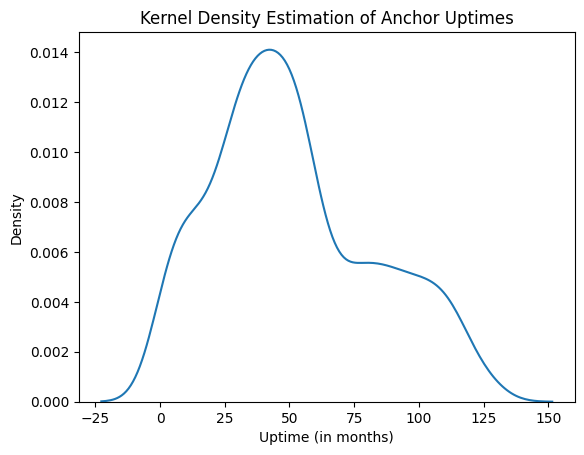

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(len(all_uptimes_anchors))
sns.kdeplot(all_uptimes_anchors)
plt.xlabel("Uptime (in months)")
plt.ylabel("Density")
plt.title("Kernel Density Estimation of Anchor Uptimes")
plt.show()


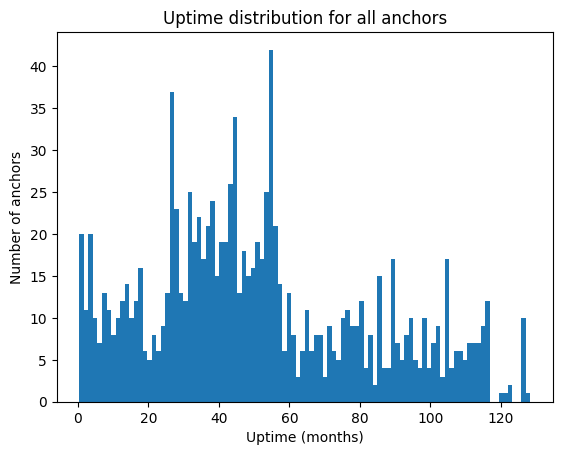

In [ ]:
import matplotlib.pyplot as plt


plt.hist(all_uptimes_anchors, bins=100)
plt.xlabel("Uptime (months)")
plt.ylabel("Number of anchors")
plt.title("Uptime distribution for all anchors")
plt.show()


In [ ]:
# to calculate unique asv4 and asv6

as_v4_set = set()
as_v6_set = set()
as_v4_v6_count = 0

for anchor in all_anchors:
    if anchor["as_v4"]:
        as_v4_set.add(anchor["as_v4"])
    if anchor["as_v6"]:
        as_v6_set.add(anchor["as_v6"])
    if anchor["as_v4"] and anchor["as_v6"]:
        as_v4_v6_count += 1

print("Number of unique as_v4 values:", len(as_v4_set))
print("Number of unique as_v6 values:", len(as_v6_set))
print("Number of anchors with both as_v4 and as_v6 values:", as_v4_v6_count)


Number of unique as_v4 values: 783
Number of unique as_v6 values: 705
Number of anchors with both as_v4 and as_v6 values: 1126


In [ ]:
count_is_ipv4_only_false = 0

for anchor in all_anchors:
    if not anchor["is_ipv4_only"]:
        count_is_ipv4_only_false += 1

print(f"{count_is_ipv4_only_false} anchors have is_ipv4_only as false")


1113 anchors have is_ipv4_only as false


In [ ]:
country_counts = {}

for anchor in all_anchors:
    country = anchor["country"]
    if country in country_counts:
        country_counts[country] += 1
    else:
        country_counts[country] = 1

for country, count in country_counts.items():
    print(f"{country}: {count}")


In [ ]:
city_count = {}
for anchor in all_anchors:
    country = anchor.get("country")
    city = anchor.get("city")
    if country is None or city is None:
        continue
    if country not in city_count:
        city_count[country] = {}
    if city not in city_count[country]:
        city_count[country][city] = 0
    city_count[country][city] += 1

for country, city_dict in city_count.items():
    print(f"Country: {country}")
    for city, count in city_dict.items():
        print(f"\tCity: {city} | Count: {count}")


To build map for the locations

In [ ]:
# import folium

# # Create a map centered at the coordinates of your choice
# m = folium.Map(location=[0, 0], zoom_start=2)

# # Add markers to the map for each anchor
# for anchor in all_anchors:
#     # coords = anchor['geometry']['coordinates']
#     print([anchor['geometry']['coordinates'][0], anchor['geometry']['coordinates'][1]])
#     # folium.Marker(location=[anchor['geometry']['coordinates'][0], anchor['geometry']['coordinates'][1]]).add_to(m)

# # Display the map
# # m

import folium

# Create an empty list to store coordinates
coordinates_list = []

# Loop through all anchors and add coordinates to the list
for anchor in all_anchors:
    coordinates_list.append(
        [anchor["geometry"]["coordinates"][1], anchor["geometry"]["coordinates"][0]]
    )

# Create a map centered at the middle of the world
m = folium.Map(location=[0, 0], zoom_start=2.5)

# Add markers for each coordinate to the map
for coordinates in coordinates_list:
    folium.Marker(location=coordinates).add_to(m)

# Display the map
m


In [ ]:
# import folium

# # Create a map centered at the middle of the world coordinate
# m = folium.Map(location=[0, 0], zoom_start=2)

# # Add markers for the coordinates
# folium.Marker(location=[-33.9181984, 151.1893], popup="Sydney, Australia").add_to(m)
# # folium.Marker(location=[46.6160291, 14.2652247], popup="Austria").add_to(m)

# # Display the map
# m


In [ ]:
import folium

# Create an empty dictionary to store the number of anchors at each coordinate
anchor_counts = {}

# Loop through all anchors and count the number of anchors at each coordinate
for anchor in all_anchors:
    coordinates = (
        anchor["geometry"]["coordinates"][1],
        anchor["geometry"]["coordinates"][0],
    )
    if coordinates in anchor_counts:
        anchor_counts[coordinates] += 1
    else:
        anchor_counts[coordinates] = 1

# Create a map centered at the middle of the world
m = folium.Map(location=[0, 0], zoom_start=2.5)

# Loop through all coordinates and add markers to the map
for coordinates, count in anchor_counts.items():
    # Choose a color based on the number of anchors at the coordinate
    if count > 3:
        color = "red"
    elif count > 1:
        color = "orange"
    else:
        color = "green"
    # Create a marker with a size based on the number of anchors at the coordinate
    radius = min(10, count) * 2
    marker = folium.CircleMarker(
        location=coordinates, radius=radius, color=color, fill=True, fill_color=color
    )
    # Add the marker to the map
    marker.add_to(m)

# Display the map
m


In [ ]:
country_ases = {}

# Loop through all anchors and count the number of ASes per country
for anchor in all_anchors:
    country = anchor["country"]
    as_v4 = anchor["as_v4"]
    if country not in country_ases:
        country_ases[country] = 0
    country_ases[country] += 1

# Sort the countries based on the number of ASes
sorted_countries = sorted(country_ases.items(), key=lambda x: x[1], reverse=True)

# Print the top 40 countries
for i, country in enumerate(sorted_countries[:40]):
    print(f"{i+1}. {country[0]}- {country[1]} \\\ ")


## finding top 40 countries based on the AS and uptime > 25

In [ ]:
from datetime import datetime

# Current time
current_time = datetime.now()

# List of format strings to try for date_live field
date_live_formats = ["%Y-%m-%dT%H:%M:%S.%f", "%Y-%m-%dT%H:%M:%S"]

# Dictionary to store the number of ASes for each country
as_count = {}

country_ases = {}

# Loop through each anchor
for anchor in all_anchors:
    # Skip anchors that are IPv4 only
    if anchor["is_ipv4_only"]:
        continue

    # Get the date_live field
    date_live_str = anchor["date_live"]

    # Check if the date_live field is empty or null
    if not date_live_str:
        continue

    # Try to parse the date_live field using each format string in date_live_formats
    for date_live_format in date_live_formats:
        try:
            date_live_obj = datetime.strptime(date_live_str, date_live_format)
            break
        except ValueError:
            pass

    # Calculate the uptime in months
    time_diff_seconds = (current_time - date_live_obj).total_seconds()
    time_diff_months = int(time_diff_seconds) // 2592000  # 2592000 seconds = 1 month

    # Skip anchors with uptime less than 25 months
    if time_diff_months < 25:
        continue

    # Get the country name and AS count for the anchor
    country = anchor["country"]
    as_v4 = anchor["as_v4"]
    if country not in country_ases:
        country_ases[country] = 0
    country_ases[country] += 1

    # Add the AS count to the total for the country
    # if country in as_count:
    #     as_count[country] += as_count_for_anchor
    # else:
    #     as_count[country] = as_count_for_anchor

# Sort the countries based on the number of ASes
sorted_countries = sorted(country_ases.items(), key=lambda x: x[1], reverse=True)

# Print the top 40 countries
for i, country in enumerate(sorted_countries[:40]):
    print(country[0])
    # print(f"{i+1}. {country[0]}- {country[1]} \\\ ")

# # Sort the dictionary in descending order of the AS count
# sorted_as_count = {k: v for k, v in sorted(as_count.items(), key=lambda item: item[1], reverse=True)}

# # Print the sorted dictionary
# print(sorted_as_count)


## marking the top 40 countries

In [ ]:
import folium

# Create a map centered at a particular location
m = folium.Map(location=[20, 0], zoom_start=2)

# List of countries to mark on the map
country_codes = [
    "US",
    "DE",
    "FR",
    "NL",
    "GB",
    "CH",
    "CA",
    "RU",
    "AU",
    "SG",
    "KZ",
    "CZ",
    "IT",
    "DK",
    "AT",
    "SE",
    "BG",
    "JP",
    "BR",
    "ZA",
    "FI",
    "LU",
    "PL",
    "UA",
    "BE",
    "ES",
    "HK",
    "IE",
    "NZ",
    "AE",
    "IR",
    "CL",
    "EE",
    "IN",
    "NO",
    "RO",
    "GR",
    "ID",
    "KR",
    "PT",
]

# Iterate through anchors and mark the ones that correspond to the countries in country_codes
for anchor in all_anchors:
    if anchor["country"] in country_codes:
        lat, lng = anchor["geometry"]["coordinates"]
        folium.Marker(location=[lng, lat]).add_to(m)

# Display the map
m
